# Kako vpliva povprečna bruto plača na rodnost po občinah v Sloveniji?

In [1]:
from scipy import stats
import numpy as np
import json
import urllib.request
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

COLORS = {
    "muted_olive":   "#8CB369",
    "sandy_brown":   "#F4A259",
    "blushed_brick": "#BC4B51",
    "light_blue":    "#74B3CE",
}

SLO_BRUTO_2023   = 2254.86
SLO_RODNOST_2024 = 7.9

def normalize_name(name):
    if isinstance(name, str) and '/' in name:
        return name.split('/')[0].strip()
    return name

df_placa = pd.read_csv('data/raw/csv/obcine_avg_placa.csv',
                        encoding='cp1250', sep=';', skiprows=2,
                        decimal='.', na_values=['z'])
df_placa.columns = ['obcina', 'bruto_2023', 'bruto_2024', 'bruto_2025',
                     'neto_2023', 'neto_2024', 'neto_2025']
df_placa = df_placa[df_placa['obcina'] != 'SLOVENIJA'].copy()
df_placa['obcina_norm'] = df_placa['obcina'].apply(normalize_name)
df_placa['bruto_2023']  = pd.to_numeric(df_placa['bruto_2023'], errors='coerce')

rod_raw = pd.read_csv('data/raw/csv/obcine_rodnost.csv',
                       encoding='cp1250', sep=';', skiprows=2,
                       na_values=['-', 'z'])
rod_cols = ['obcina'] + [f'{t}_{y}' for y in range(1995, 2025)
                                     for t in ['skupaj', 'na1000']]
rod_raw.columns = rod_cols

rod = (rod_raw[rod_raw['obcina'] != 'SLOVENIJA']
              [['obcina', 'skupaj_2024', 'na1000_2024']]
              .copy())
rod.columns = ['obcina', 'skupaj_2024', 'rodnost_2024']
rod['rodnost_2024'] = pd.to_numeric(rod['rodnost_2024'], errors='coerce')
rod['obcina_norm']  = rod['obcina'].apply(normalize_name)

df_merge = (
    df_placa[['obcina', 'obcina_norm', 'bruto_2023']]
    .merge(rod[['obcina_norm', 'rodnost_2024']], on='obcina_norm')
    .dropna(subset=['bruto_2023', 'rodnost_2024'])
    .reset_index(drop=True)
)

min_row = df_merge.loc[df_merge['rodnost_2024'].idxmin()]
max_row = df_merge.loc[df_merge['rodnost_2024'].idxmax()]
print(f"Število občin v analizi : {len(df_merge) + 1}")
print(f"Povprečna rodnost (2024): {df_merge['rodnost_2024'].mean():.2f}")
print(f"Najnižja rodnost        : {min_row['rodnost_2024']:.1f}  -  {min_row['obcina']}")
print(f"Najvišja rodnost        : {max_row['rodnost_2024']:.1f}  -  {max_row['obcina']}")

Število občin v analizi : 212
Povprečna rodnost (2024): 8.03
Najnižja rodnost        : 2.9  -  Hodoš/Hodos
Najvišja rodnost        : 18.0  -  Jezersko


V spodnji analizi primerjamo ekonomski razvoj, merjen s povprečno bruto plačo (2023), z demografskim trendom - rodnostjo (živorojeni na 1.000 prebivalcev, 2024) - po vseh slovenskih občinah. Cilj je ugotoviti, ali obstaja sistematična povezava med prihodki in rodnostjo na ravni lokalne skupnosti.

Za razliko od analize po regijah (12 enot) nam analiza na ravni občin ponudi bistveno večji vzorec (~200 občin), kar omogoča zanesljivejše statistične zaključke.

Občine delimo v 4 kvadrante glede na slovensko povprečje plač (2.255 €) in rodnosti (7,9 ‰):
- **Visoka plača & visoka rodnost** - demografsko in ekonomsko vitalne skupnosti
- **Visoka plača & nizka rodnost** - ekonomsko razvite, a demografsko šibkejše občine
- **Nizka plača & visoka rodnost** - živahne ruralne skupnosti kljub nižjim prihodkom
- **Nizka plača & nizka rodnost** - demografsko in ekonomsko ogrožena območja

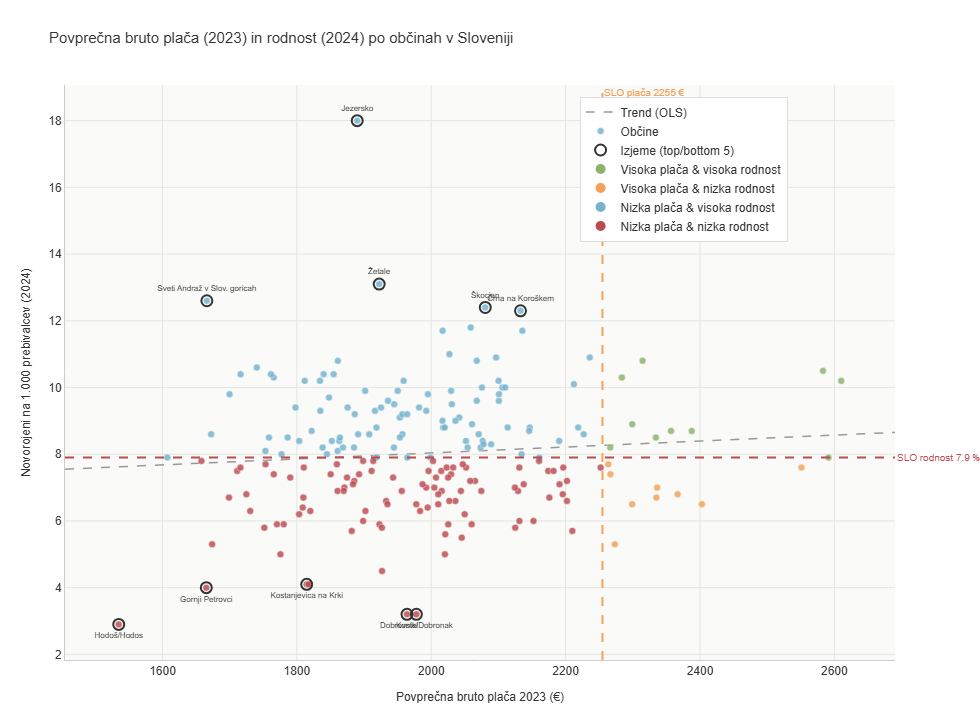

In [2]:
def get_color(row):
    hp = row['bruto_2023']  >= SLO_BRUTO_2023
    hr = row['rodnost_2024'] >= SLO_RODNOST_2024
    if  hp and  hr: return COLORS['muted_olive']
    if  hp and not hr: return COLORS['sandy_brown']
    if not hp and  hr: return COLORS['light_blue']
    return COLORS['blushed_brick']

df_merge['color'] = df_merge.apply(get_color, axis=1)

slope, intercept, r_val, p_val, _ = stats.linregress(
    df_merge['bruto_2023'], df_merge['rodnost_2024']
)
x_fit = np.linspace(df_merge['bruto_2023'].min() - 80,
                     df_merge['bruto_2023'].max() + 80, 120)
y_fit = slope * x_fit + intercept

top5 = df_merge.nlargest(5, 'rodnost_2024')
bot5 = df_merge.nsmallest(5, 'rodnost_2024')
extremes = pd.concat([top5, bot5])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_fit, y=y_fit,
    mode='lines',
    line=dict(color='#999999', width=1.5, dash='dash'),
    name='Trend (OLS)',
    hoverinfo='skip'
))

fig.add_trace(go.Scatter(
    x=df_merge['bruto_2023'],
    y=df_merge['rodnost_2024'],
    mode='markers',
    marker=dict(size=7, color=df_merge['color'],
                line=dict(color='white', width=0.5), opacity=0.82),
    text=df_merge['obcina'],
    name='Občine',
    hovertemplate='<b>%{text}</b><br>Bruto plača: %{x:.0f} €<br>Rodnost: %{y:.1f} ‰<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=extremes['bruto_2023'],
    y=extremes['rodnost_2024'],
    mode='markers+text',
    marker=dict(size=11, color='#333333', symbol='circle-open',
                line=dict(color='#333333', width=2)),
    text=extremes['obcina'],
    textposition=['top center' if r >= SLO_RODNOST_2024 else 'bottom center'
                  for r in extremes['rodnost_2024']],
    textfont=dict(size=8, color='#333333'),
    name='Izjeme (top/bottom 5)',
    hovertemplate='<b>%{text}</b><br>%{x:.0f} €, %{y:.1f} ‰<extra></extra>'
))

for label, color in [
    ('Visoka plača & visoka rodnost', COLORS['muted_olive']),
    ('Visoka plača & nizka rodnost',  COLORS['sandy_brown']),
    ('Nizka plača & visoka rodnost',  COLORS['light_blue']),
    ('Nizka plača & nizka rodnost',   COLORS['blushed_brick']),
]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=10, color=color), name=label
    ))

fig.add_vline(
    x=SLO_BRUTO_2023, line_dash='dash',
    line_color=COLORS['sandy_brown'], line_width=2,
    annotation_text=f'SLO plača {SLO_BRUTO_2023:.0f} €',
    annotation_position='top right',
    annotation_font=dict(color=COLORS['sandy_brown'], size=10)
)
fig.add_hline(
    y=SLO_RODNOST_2024, line_dash='dash',
    line_color=COLORS['blushed_brick'], line_width=2,
    annotation_text=f'SLO rodnost {SLO_RODNOST_2024} ‰',
    annotation_position='right',
    annotation_font=dict(color=COLORS['blushed_brick'], size=10)
)

fig.update_layout(
    title='Povprečna bruto plača (2023) in rodnost (2024) po občinah v Sloveniji',
    width=980, height=720,
    plot_bgcolor='#FAFAF8', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    title_font=dict(size=15, color='#333333'),
    xaxis=dict(
        title='Povprečna bruto plača 2023 (€)',
        gridcolor='#E5E5E0', showline=True, linecolor='#CCCCCC',
        title_font=dict(size=12, color='#333333'),
        tickfont=dict(color='#333333')
    ),
    yaxis=dict(
        title='Novorojeni na 1.000 prebivalcev (2024)',
        gridcolor='#E5E5E0', showline=True, linecolor='#CCCCCC',
        title_font=dict(size=12, color='#333333'),
        tickfont=dict(color='#333333')
    ),
    legend=dict(
        x=0.62, y=0.98,
        bgcolor='rgba(255,255,255,0.92)',
        bordercolor='#DDDDDD', borderwidth=1,
        font=dict(color='#333333')
    ),
    margin=dict(l=65, r=85, t=85, b=60)
)

pio.renderers.default = 'png'
fig.show()

Razsevni diagram kaže porazdelitev ~200 občin po dveh dimenzijah. Vsaka točka je ena občina, barva označuje kvadrant glede na slovensko povprečje.

Regresijska premica (siva, prekinjena) nakazuje splošen trend. Izstopajoče vrednosti pri rodnosti pogosto pripadata **majhnim občinam** (npr. Dobje, Hodoš, Kobilje), kjer že en otrok več ali manj bistveno vpliva na stopnjo na 1.000 prebivalcev - te vrednosti je treba interpretirati previdno.

**Omejitev**: Majhne občine (< ~500 preb.) imajo statistično nestabilne stopnje rodnosti in nagnjenost k ekstremnim vrednostim.

### Rangirana primerjava plače in rodnosti za vse občine

Vsaka občina je prikazana kot par točk na isti vrstici:
- krog = percentilni rang plače
- diamant = percentilni rang rodnosti

Občine so razvrščene od **najnižjega skupnega ranga** (spodaj) do **najvišjega** (zgoraj). Kjer sta točki blizu skupaj, se obe vrednosti ujemata - kar je dokaz pozitivne korelacije. Dolge črte kažejo na občine, kjer plača in rodnost gresta v nasprotno smer.

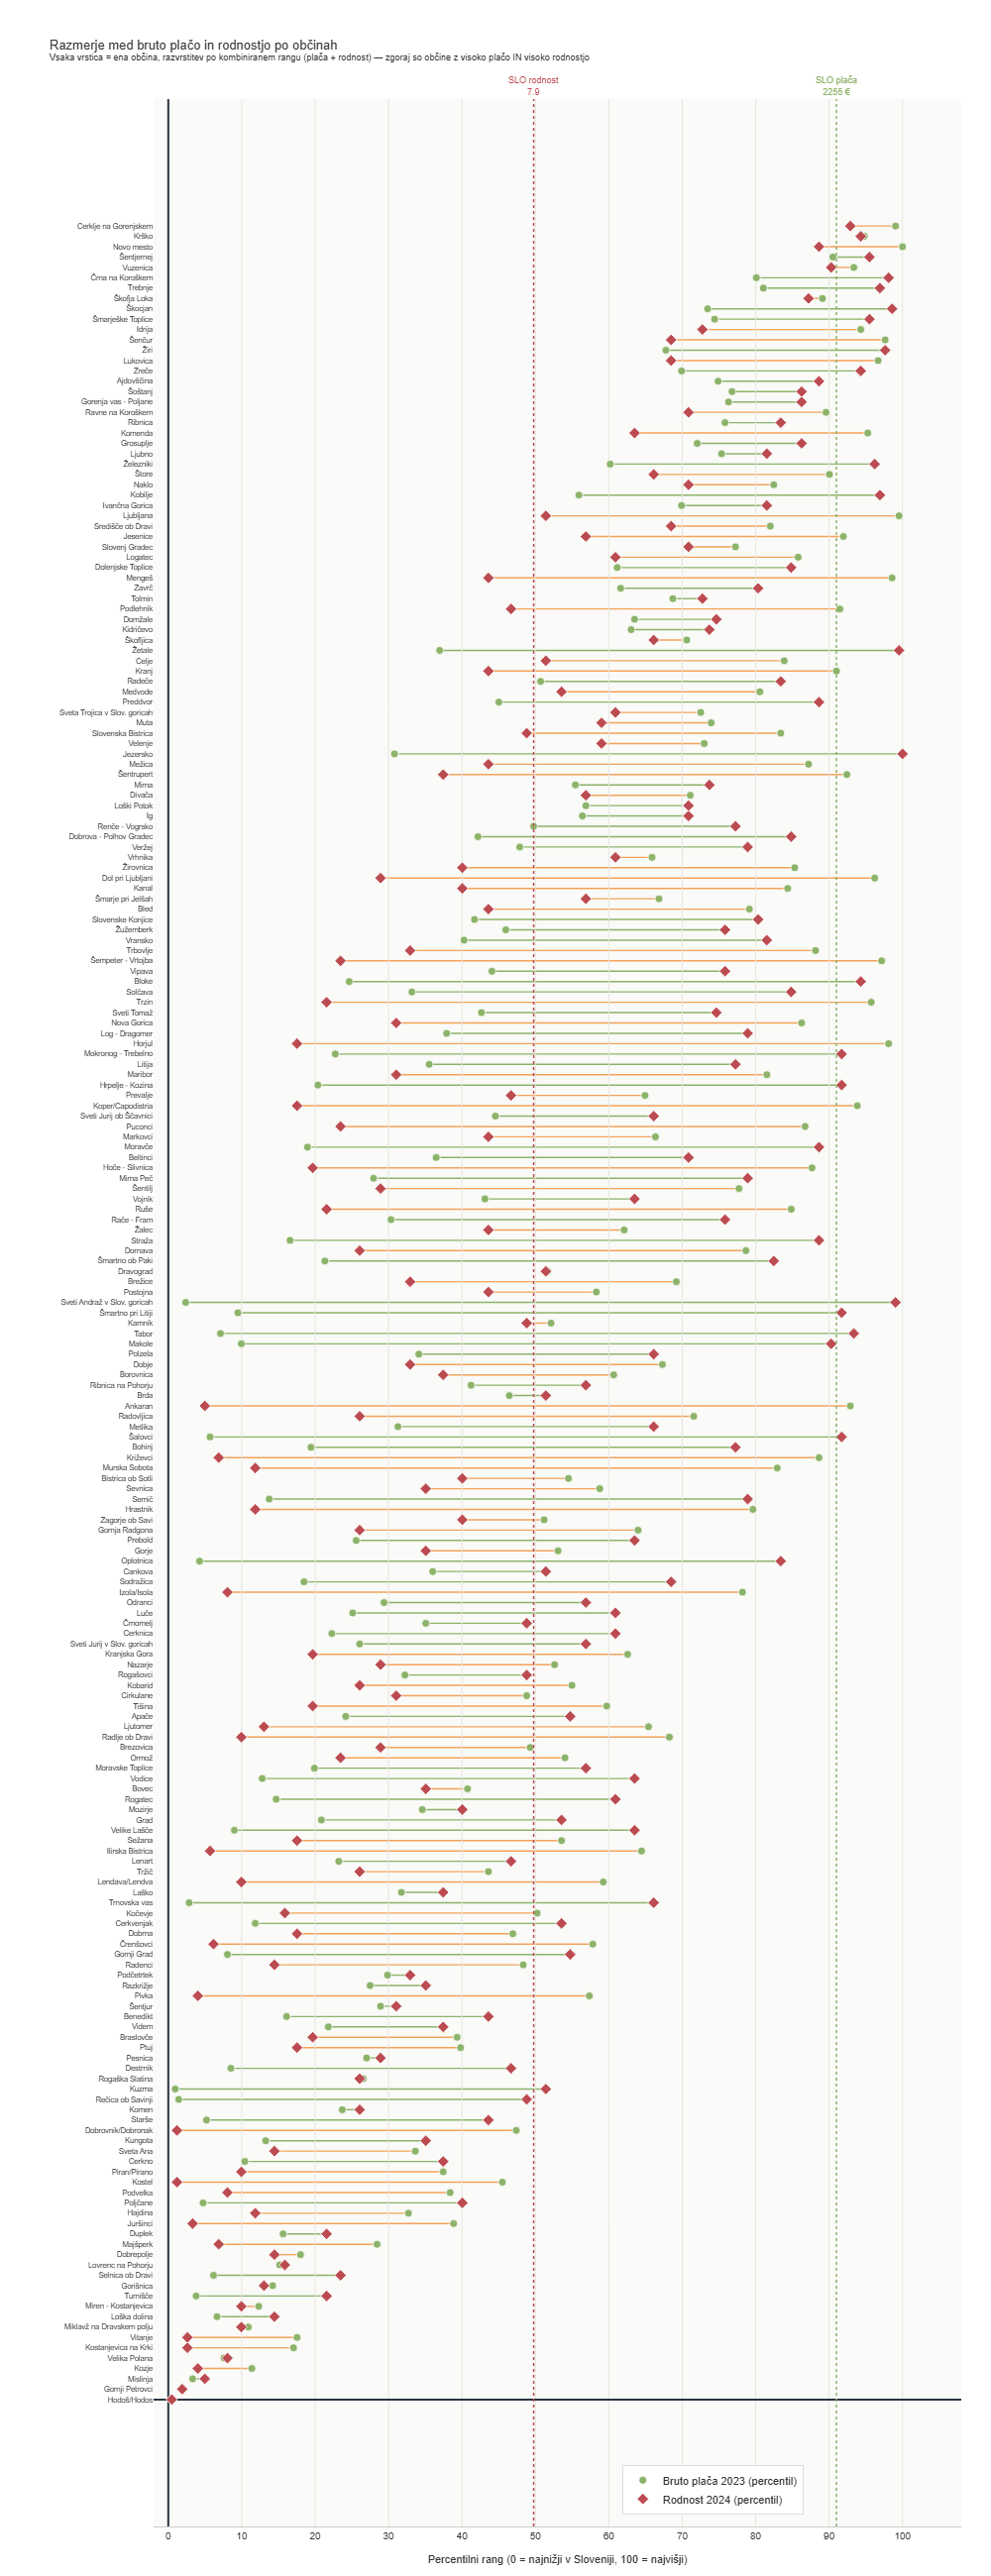

In [3]:
df_db = df_merge.copy()

df_db['placa_pct'] = df_db['bruto_2023'].rank(pct=True) * 100
df_db['rod_pct']   = df_db['rodnost_2024'].rank(pct=True) * 100
df_db['combined']  = (df_db['placa_pct'] + df_db['rod_pct']) / 2

df_db = df_db.sort_values('combined', ascending=True).reset_index(drop=True)

n = len(df_db)
y_vals = list(range(n))

fig = go.Figure()

for i, row in df_db.iterrows():
    line_col = COLORS['muted_olive'] if row['rod_pct'] >= row['placa_pct'] else COLORS['sandy_brown']
    fig.add_shape(
        type='line',
        x0=row['placa_pct'], x1=row['rod_pct'],
        y0=i, y1=i,
        line=dict(color=line_col, width=1.4),
        layer='below'
    )

fig.add_trace(go.Scatter(
    x=df_db['placa_pct'],
    y=y_vals,
    mode='markers',
    marker=dict(
        size=8,
        color=COLORS['muted_olive'],
        symbol='circle',
        line=dict(color='white', width=0.8)
    ),
    name='Bruto plača 2023 (percentil)',
    customdata=df_db[['obcina', 'bruto_2023', 'placa_pct']].values,
    hovertemplate='<b>%{customdata[0]}</b><br>Bruto plača: %{customdata[1]:.0f} €<br>Percentil: %{customdata[2]:.1f}%<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=df_db['rod_pct'],
    y=y_vals,
    mode='markers',
    marker=dict(
        size=9,
        color=COLORS['blushed_brick'],
        symbol='diamond',
        line=dict(color='white', width=0.8)
    ),
    name='Rodnost 2024 (percentil)',
    customdata=df_db[['obcina', 'rodnost_2024', 'rod_pct']].values,
    hovertemplate='<b>%{customdata[0]}</b><br>Rodnost: %{customdata[1]:.1f} <br>Percentil: %{customdata[2]:.1f}%<extra></extra>'
))

slo_placa_pct = (df_db['bruto_2023'] < SLO_BRUTO_2023).mean() * 100
slo_rod_pct   = (df_db['rodnost_2024'] < SLO_RODNOST_2024).mean() * 100

fig.add_vline(x=slo_placa_pct, line_dash='dot', line_color=COLORS['muted_olive'], line_width=1.5,
              annotation_text=f'SLO plača<br>{SLO_BRUTO_2023:.0f} €',
              annotation_position='top',
              annotation_font=dict(color=COLORS['muted_olive'], size=9))
fig.add_vline(x=slo_rod_pct, line_dash='dot', line_color=COLORS['blushed_brick'], line_width=1.5,
              annotation_text=f'SLO rodnost<br>{SLO_RODNOST_2024}',
              annotation_position='top',
              annotation_font=dict(color=COLORS['blushed_brick'], size=9))

fig.update_layout(
    title=dict(
        text=(
            'Razmerje med bruto plačo in rodnostjo po občinah<br>'
            '<sup>Vsaka vrstica = ena občina, razvrstitev po kombiniranem rangu (plača + rodnost) — '
            'zgoraj so občine z visoko plačo IN visoko rodnostjo</sup>'
        ),
        font=dict(size=13, color='#333333')
    ),
    width=1000,
    height=max(2600, n * 12),
    plot_bgcolor='#FAFAF8',
    paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=10, color='#333333'),
    xaxis=dict(
        title='Percentilni rang (0 = najnižji v Sloveniji, 100 = najvišji)',
        range=[-2, 108],
        gridcolor='#E5E5E0',
        showline=True,
        linecolor='#CCCCCC',
        dtick=10,
        tickfont=dict(size=10),
        title_font=dict(size=11)
    ),
    yaxis=dict(
        tickvals=y_vals,
        ticktext=df_db['obcina'].tolist(),
        tickfont=dict(size=7.5),
        showgrid=False,
    ),
    legend=dict(
        x=0.58, y=0.005,
        bgcolor='rgba(255,255,255,0.92)',
        bordercolor='#DDDDDD',
        borderwidth=1,
        font=dict(size=11)
    ),
    margin=dict(l=155, r=30, t=100, b=50),
)

pio.renderers.default = 'png'
fig.show()


### Rangiranje občin po rodnosti in njihova povprečna bruto plača

Poglejmo si 20 občin z **najvišjo** in 20 občin z **najnižjo** rodnostjo (2024) ter preverimo, ali gre za ekonomsko močnejše ali šibkejše skupnosti.

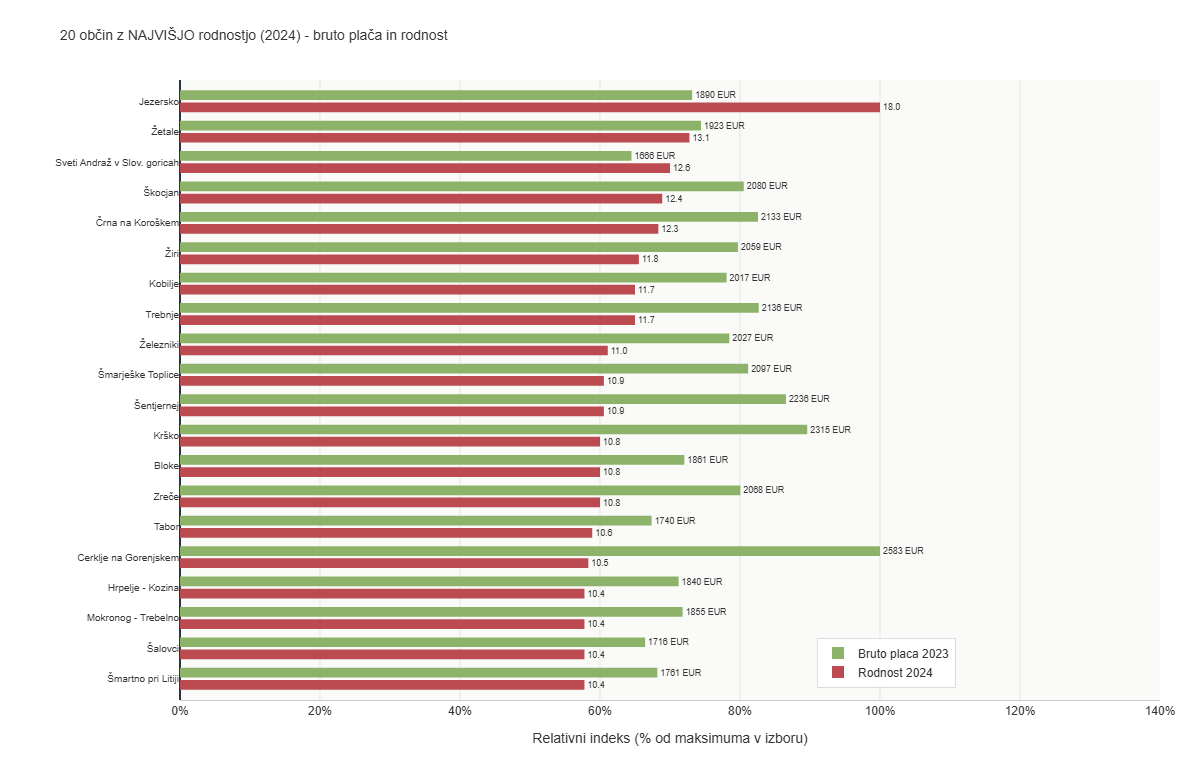

In [4]:
top20 = (df_merge.nlargest(20, 'rodnost_2024')
                 .sort_values('rodnost_2024', ascending=True)
                 .reset_index(drop=True))

top20['placa_idx'] = top20['bruto_2023']   / top20['bruto_2023'].max()   * 100
top20['rod_idx']   = top20['rodnost_2024'] / top20['rodnost_2024'].max() * 100

y_placa = [i * 2.5 + 1.0 for i in range(len(top20))]
y_rod   = [i * 2.5 + 0.0 for i in range(len(top20))]
y_ticks = [i * 2.5 + 0.5 for i in range(len(top20))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top20['placa_idx'], y=y_placa,
    orientation='h',
    marker_color=COLORS['muted_olive'], marker_line_width=0,
    name='Bruto placa 2023',
    text=[f'{v:.0f} EUR' for v in top20['bruto_2023']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=top20['bruto_2023'],
    hovertemplate='<b>%{customdata:.0f} EUR</b><extra>Bruto placa</extra>'
))

fig.add_trace(go.Bar(
    x=top20['rod_idx'], y=y_rod,
    orientation='h',
    marker_color=COLORS['blushed_brick'], marker_line_width=0,
    name='Rodnost 2024',
    text=[f'{v:.1f}' for v in top20['rodnost_2024']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=top20['rodnost_2024'],
    hovertemplate='<b>%{customdata:.1f} prom</b><extra>Rodnost</extra>'
))

fig.update_layout(
    title='20 občin z NAJVIŠJO rodnostjo (2024) - bruto plača in rodnost',
    barmode='overlay',
    width=1200, height=760,
    plot_bgcolor='#FAFAF8', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    title_font=dict(size=14, color='#333333'),
    xaxis=dict(
        title='Relativni indeks (% od maksimuma v izboru)',
        range=[0, 140], ticksuffix='%',
        gridcolor='#E5E5E0', showline=True, linecolor='#CCCCCC',
        tickfont=dict(color='#333333')
    ),
    yaxis=dict(
        tickvals=y_ticks,
        ticktext=top20['obcina'].tolist(),
        tickfont=dict(size=10, color='#333333'),
        showgrid=False
    ),
    legend=dict(x=0.65, y=0.02, bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#DDDDDD', borderwidth=1, font=dict(color='#333333')),
    margin=dict(l=180, r=40, t=80, b=60)
)

pio.renderers.default = 'png'
fig.show()

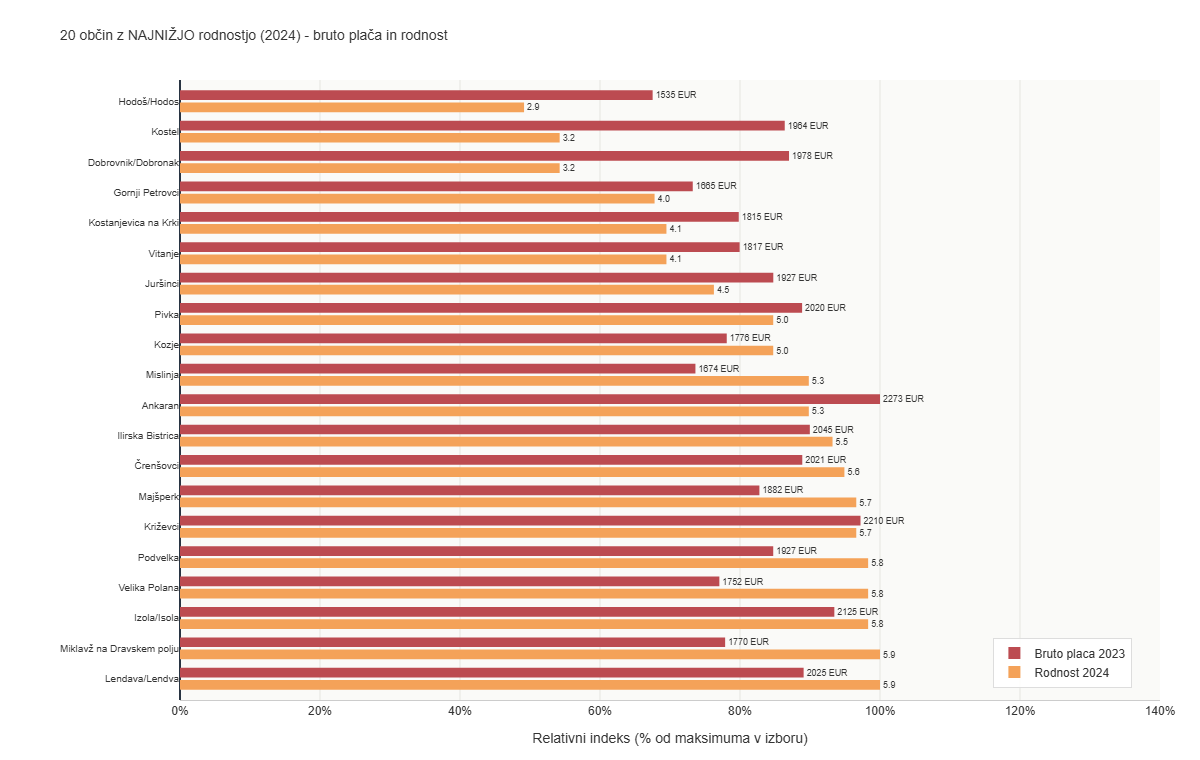

In [5]:
bot20 = (df_merge.nsmallest(20, 'rodnost_2024')
                 .sort_values('rodnost_2024', ascending=False)
                 .reset_index(drop=True))

bot20['placa_idx'] = bot20['bruto_2023']   / bot20['bruto_2023'].max()   * 100
bot20['rod_idx']   = bot20['rodnost_2024'] / bot20['rodnost_2024'].max() * 100

y_placa = [i * 2.5 + 1.0 for i in range(len(bot20))]
y_rod   = [i * 2.5 + 0.0 for i in range(len(bot20))]
y_ticks = [i * 2.5 + 0.5 for i in range(len(bot20))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=bot20['placa_idx'], y=y_placa,
    orientation='h',
    marker_color=COLORS['blushed_brick'], marker_line_width=0,
    name='Bruto placa 2023',
    text=[f'{v:.0f} EUR' for v in bot20['bruto_2023']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=bot20['bruto_2023'],
    hovertemplate='<b>%{customdata:.0f} EUR</b><extra>Bruto placa</extra>'
))

fig.add_trace(go.Bar(
    x=bot20['rod_idx'], y=y_rod,
    orientation='h',
    marker_color=COLORS['sandy_brown'], marker_line_width=0,
    name='Rodnost 2024',
    text=[f'{v:.1f}' for v in bot20['rodnost_2024']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=bot20['rodnost_2024'],
    hovertemplate='<b>%{customdata:.1f} prom</b><extra>Rodnost</extra>'
))

fig.update_layout(
    title='20 občin z NAJNIŽJO rodnostjo (2024) - bruto plača in rodnost',
    barmode='overlay',
    width=1200, height=760,
    plot_bgcolor='#FAFAF8', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    title_font=dict(size=14, color='#333333'),
    xaxis=dict(
        title='Relativni indeks (% od maksimuma v izboru)',
        range=[0, 140], ticksuffix='%',
        gridcolor='#E5E5E0', showline=True, linecolor='#CCCCCC',
        tickfont=dict(color='#333333')
    ),
    yaxis=dict(
        tickvals=y_ticks,
        ticktext=bot20['obcina'].tolist(),
        tickfont=dict(size=10, color='#333333'),
        showgrid=False
    ),
    legend=dict(x=0.83, y=0.02, bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#DDDDDD', borderwidth=1, font=dict(color='#333333')),
    margin=dict(l=180, r=40, t=80, b=60)
)

pio.renderers.default = 'png'
fig.show()

Za objektivno oceno povezanosti smo izračunali Pearsonov in Spearmanov koeficient korelacije. Za razliko od regijske analize (n = 12) nam ~200 občin zagotavlja bistveno večjo statistično moč.

In [6]:
r,    p    = stats.pearsonr( df_merge['bruto_2023'], df_merge['rodnost_2024'])
r_sp, p_sp = stats.spearmanr(df_merge['bruto_2023'], df_merge['rodnost_2024'])

smer = 'pozitivna' if r > 0 else 'negativna'
moc  = 'šibka' if abs(r) < 0.3 else 'zmerna' if abs(r) < 0.6 else 'močna'
sig  = ('statistično značilna (p < 0,05)'
        if p < 0.05 else 'ni statistično značilna (p ≥ 0,05)')

print(f"Pearsonov r  = {r:.3f}   (p = {p:.4f})")
print(f"Spearmanov ρ = {r_sp:.3f}   (p = {p_sp:.4f})")
print()
print(f"Med povprečno bruto plačo občin (2023) in rodnostjo (2024) obstaja")
print(f"{moc} {smer} korelacija (r = {r:.3f}), ki {sig}.")

Pearsonov r  = 0.088   (p = 0.2010)
Spearmanov ρ = 0.070   (p = 0.3108)

Med povprečno bruto plačo občin (2023) in rodnostjo (2024) obstaja
šibka pozitivna korelacija (r = 0.088), ki ni statistično značilna (p ≥ 0,05).


**Smer in moč**: Korelacija med plačo in rodnostjo je na ravni občin praviloma šibkejša kot na ravni regij. Razlog je v tem, da regije »zgladijo« lokalne posebnosti, medtem ko občinski podatki razkrijejo precejšnjo heterogenost - na rodnost vplivajo dejavniki, ki se ne ujemajo nujno z ekonomskim nivojem (ruralna tradicija, verska skupnost, demografska struktura, bližina vrtcev ipd.).

**Primerjava z regijsko analizo**: V analizi po regijah smo ugotovili zmerno pozitivno korelacijo (r = 0,507, p = 0,092). Analiza po občinah z bistveno večjim vzorcem (~200 točk) poda bolj zanesljivo oceno - statistična značilnost je pri tako velikem n dosežena že pri šibkejši korelaciji.

**Izstopajoči primeri**: Nekatere majhne ruralne občine (Dobje, Benedikt, Gorenja vas - Poljane) izstopajo z nadpovprečno rodnostjo kljub povprečnim ali podpovprečnim plačam, kar kaže, da plača ni edini - ali celo prevladujoči - napovedovalec rodnosti na lokalni ravni.

### Toplotna karta povprečne bruto plače po občinah (2023)

Spodnja **karta (heat map)** prikazuje prostorsko porazdelitev povprečnih bruto plač po vseh slovenskih občinah za leto 2023. Barva vsake občine kodira njeno povprečno bruto plačo - rdeči odtenki označujejo višje plače. Karta temelji na uradnih mejah občin iz GURS-a (GeoJSON).

Opazimo jasno prostorsko ločnico: **osrednja Slovenija** (Ljubljana in okolica) ter **Jugovzhodna Slovenija** izstopata z nadpovprečnimi plačami, medtem ko **Pomurje** in deli **Podravja** zaostajajo.

Ujemanje: 212/212 občin


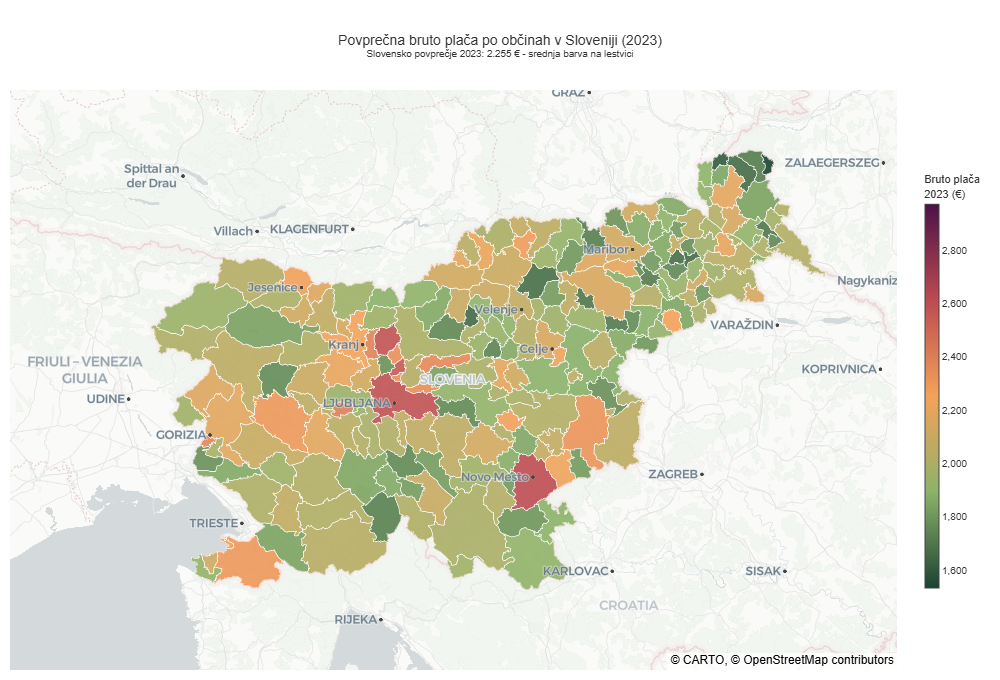

In [7]:
GEOJSON_URL = 'https://raw.githubusercontent.com/stefanb/gurs-rpe/master/data/OB.geojson'
with urllib.request.urlopen(GEOJSON_URL) as resp:
    geojson_data = json.loads(resp.read())

def normalize_name(name):
    if not isinstance(name, str):
        return name
    if '/' in name:
        name = name.split('/')[0].strip()
    name = name.replace(' - ', '-')
    name = name.replace('Slov. goricah', 'Slovenskih goricah')
    return name

for feat in geojson_data['features']:
    feat['id'] = normalize_name(feat['properties']['OB_UIME'])

df_placa = pd.read_csv('data/raw/csv/obcine_avg_placa.csv',
                        encoding='cp1250', sep=';', skiprows=2,
                        decimal='.', na_values=['z'])
df_placa.columns = ['obcina', 'bruto_2023', 'bruto_2024', 'bruto_2025',
                     'neto_2023', 'neto_2024', 'neto_2025']
df_placa = df_placa[df_placa['obcina'] != 'SLOVENIJA'].copy()
df_placa['bruto_2023'] = pd.to_numeric(df_placa['bruto_2023'], errors='coerce')
df_placa['obcina_norm'] = df_placa['obcina'].apply(normalize_name)

geo_ids = {f['id'] for f in geojson_data['features']}
matched = df_placa['obcina_norm'].isin(geo_ids).sum()
print(f"Ujemanje: {matched}/{len(df_placa)} občin")

SLO_BRUTO_2023 = 2254.86

fig = go.Figure(go.Choroplethmap(
    geojson=geojson_data,
    locations=df_placa['obcina_norm'],
    z=df_placa['bruto_2023'],
    customdata=df_placa[['obcina', 'bruto_2023']].values,
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'Bruto plača 2023: %{customdata[1]:,.0f} €'
        '<extra></extra>'
    ),
    colorscale=[
        [0.00, '#1B4332'],
        [0.25, '#8CB369'],
        [0.50, '#F4A259'],
        [0.75, '#BC4B51'],
        [1.00, '#4B1248'],
    ],
    zmid=SLO_BRUTO_2023,
    colorbar=dict(
        title=dict(text='Bruto plača<br>2023 (€)', font=dict(size=11, color='#333333')),
        tickfont=dict(size=10, color='#333333'),
        tickformat=',.0f',
        len=0.75,
        thickness=14,
    ),
    marker_line_color='white',
    marker_line_width=0.5,
    marker_opacity=0.9,
))

fig.update_layout(
    title=dict(
        text=(
            'Povprečna bruto plača po občinah v Sloveniji (2023)<br>'
            '<sup>Slovensko povprečje 2023: 2.255 € - srednja barva na lestvici</sup>'
        ),
        font=dict(size=14, color='#333333'),
        x=0.5, xanchor='center',
    ),
    map=dict(
        style='carto-positron',
        center=dict(lat=46.12, lon=14.82),
        zoom=7.2,
    ),
    paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    margin=dict(l=10, r=10, t=90, b=10),
    width=1000,
    height=680,
)

pio.renderers.default = 'png'
fig.show()